# Training — temporal, no log-target

Fits every feature configuration × model with **temporal forward-chaining CV** and a chronological holdout **inside the `model` period**.

The `model` slice (and independent IOD periods) are created at the end of `data_processor.ipynb` from named date ranges. This notebook only reads `splits/<model>.csv`.

Target (`chl`) is **not** log-transformed. Skewed env predictors use `log1p`.

Set `SAVE_MODELS` / `SAVE_CONFIGS` to choose which fitted artifacts are written to `models/`.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from functools import reduce
import operator

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import HuberRegressor

from pygam import LinearGAM, s
from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import joblib
from IPython.display import HTML, display

RANDOM_STATE = 42
TEST_SIZE = 0.2          # chronological holdout *inside* the model period
CV_FOLDS = 4
SPLIT_META_PATH = Path("splits/split_meta.json")
MODELS_DIR = Path("models")
RESULTS_PATH = MODELS_DIR / "training_results.json"

TARGET = "chl"
ENV_FEATURES = ["uo", "vo", "fe", "no3", "po4", "si", "o2", "ph", "so", "spco2", "thetao", "wo"]
LOG_FEATURES = ["fe", "no3", "po4", "si", "o2", "spco2"]
GEO_FEATURES = ["latitude", "longitude"]
TIME_FEATURES = ["sin_doy", "cos_doy"]

# Which artifacts to write. Training still runs every config × model for the table.
# Use None to save every model / every config.
SAVE_MODELS = ["XGBoost"]
SAVE_CONFIGS = ["env+lat_lon+time"]

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
pd.set_option("display.max_colwidth", 80)


In [2]:
# Load model-period data from data_processor splits; 80/20 temporal split inside it

if not SPLIT_META_PATH.exists():
    raise FileNotFoundError("Run data_processor.ipynb to the last cell first (writes splits/split_meta.json).")

split_meta = json.loads(SPLIT_META_PATH.read_text())
model_name = split_meta["model_bucket"]
model_path = Path(split_meta["buckets"][model_name]["path"])
if not model_path.exists():
    raise FileNotFoundError(f"Missing {model_path}")

df = pd.read_csv(model_path)
df["time"] = pd.to_datetime(df["time"], errors="coerce")
df["day_of_year"] = df["time"].dt.dayofyear
df["sin_doy"] = np.sin(2 * np.pi * df["day_of_year"] / 365.0)
df["cos_doy"] = np.cos(2 * np.pi * df["day_of_year"] / 365.0)

missing_log = [c for c in LOG_FEATURES if c not in df.columns]
if missing_log:
    raise ValueError(f"Missing log-feature columns: {missing_log}")
for col in LOG_FEATURES:
    df[col] = np.log1p(df[col])

FEATURES_FULL = ENV_FEATURES + GEO_FEATURES + TIME_FEATURES
FEATURE_CONFIGS = [
    ("env", ENV_FEATURES),
    ("lat_lon", GEO_FEATURES),
    ("time", TIME_FEATURES),
    ("env+lat_lon", ENV_FEATURES + GEO_FEATURES),
    ("env+time", ENV_FEATURES + TIME_FEATURES),
    ("lat_lon+time", GEO_FEATURES + TIME_FEATURES),
    ("env+lat_lon+time", FEATURES_FULL),
]
MODEL_ORDER = ["GAM", "RandomForest", "XGBoost", "ANN", "Huber LR"]
CONFIG_ORDER = [name for name, _ in FEATURE_CONFIGS]

need = ["time", "latitude", "longitude"] + ENV_FEATURES + [TARGET]
df = df.dropna(subset=need).sort_values("time").reset_index(drop=True)
if df.empty:
    raise ValueError(f"{model_path} has no usable rows")

n_samples = len(df)
test_size_int = max(1, int(np.floor(TEST_SIZE * n_samples)))
test_start_idx = n_samples - test_size_int
df_train = df.iloc[:test_start_idx].reset_index(drop=True)
df_test = df.iloc[test_start_idx:].reset_index(drop=True)

y_train = df_train[TARGET].values
y_test = df_test[TARGET].values

print(f"model bucket: {model_name}  file={model_path}")
print(f"rows={len(df)}  train={len(df_train)}  internal_test={len(df_test)}")
print(f"train: {df_train['time'].min().date()} → {df_train['time'].max().date()}")
print(f"internal test: {df_test['time'].min().date()} → {df_test['time'].max().date()}")
print("independent buckets (for testing.ipynb):")
for name, spec in split_meta["buckets"].items():
    if spec.get("role") != "independent":
        continue
    print(f"  {name}: n={spec['n']}  {spec['start']} → {spec['end']}  ({spec['path']})")


model bucket: model  file=splits/model.csv
rows=105909  train=84728  internal_test=21181
train: 2023-12-01 → 2025-09-17
internal test: 2025-09-17 → 2026-02-28
independent buckets (for testing.ipynb):
  IOD_negative: n=11739  2022-09-01 → 2022-11-30  (splits/IOD_negative.csv)
  IOD_positive: n=11739  2023-09-01 → 2023-11-30  (splits/IOD_positive.csv)


In [3]:
class TemporalForwardChainSplit:
    """Forward-chaining over time (no future → past leakage). Rows must be sorted by time."""

    def __init__(self, df_coords, n_splits=4, time_col="time"):
        self.df_coords = df_coords.reset_index(drop=True)
        self.n_splits = n_splits
        self.time_col = time_col
        self.df_coords[self.time_col] = pd.to_datetime(self.df_coords[self.time_col], errors="coerce")

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X=None, y=None, groups=None):
        n = len(self.df_coords)
        indices = np.arange(n)
        for k in range(1, self.n_splits + 1):
            test_start = int(n * k / (self.n_splits + 1))
            test_end = int(n * (k + 1) / (self.n_splits + 1)) if k < self.n_splits else n
            train_indices = indices[:test_start]
            test_indices = indices[test_start:test_end]
            if len(train_indices) == 0 or len(test_indices) == 0:
                continue
            yield train_indices, test_indices


cv = TemporalForwardChainSplit(df_coords=df_train[["time"]], n_splits=CV_FOLDS, time_col="time")


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    y_range = float(np.ptp(y_true))
    return {
        "r2": float(r2_score(y_true, y_pred)),
        "rmse": rmse,
        "nrmse": float(rmse / max(y_range, 1e-12)),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "median_ae": float(median_absolute_error(y_true, y_pred)),
        "mape": float(100.0 * np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8)))),
        "smape": float(100.0 * np.mean((2.0 * np.abs(y_true - y_pred)) / np.maximum(np.abs(y_true) + np.abs(y_pred), 1e-8))),
        "me": float(np.mean(y_pred - y_true)),
        "n": int(len(y_true)),
    }


def _fold_time_period(splitter, val_idx):
    times = splitter.df_coords.iloc[val_idx]["time"]
    return f"{times.min().strftime('%Y-%m-%d')} to {times.max().strftime('%Y-%m-%d')}"


def sklearn_cv(model, X, y, splitter, is_gam=False):
    scores, folds = [], []
    for fold_num, (tr, va) in enumerate(splitter.split(X), start=1):
        Xtr, Xva = X[tr], X[va]
        ytr, yva = y[tr], y[va]
        if is_gam:
            m = model()
            m.fit(Xtr, ytr)
            pred = m.predict(Xva)
        else:
            m = clone(model)
            m.fit(Xtr, ytr)
            pred = m.predict(Xva)
        r2 = float(r2_score(yva, pred))
        scores.append(r2)
        folds.append({"fold": fold_num, "time_period": _fold_time_period(splitter, va), "r2": r2, "n_val": int(len(va))})
    scores = np.asarray(scores)
    return {"mean": float(scores.mean()), "std": float(scores.std()), "folds": folds}


def build_ann(input_dim):
    model = Sequential([
        Dense(64, activation="relu", input_shape=(input_dim,)),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dropout(0.1),
        Dense(1, activation="linear"),
    ])
    model.compile(optimizer="adam", loss="mse")
    return model


def ann_cv(X, y, splitter, epochs=100, batch_size=256, patience=8):
    scores, folds = [], []
    for fold_num, (tr, va) in enumerate(splitter.split(X), start=1):
        sc = StandardScaler()
        Xtr = sc.fit_transform(X[tr])
        Xva = sc.transform(X[va])
        ytr, yva = y[tr], y[va]
        m = build_ann(Xtr.shape[1])
        m.fit(
            Xtr, ytr,
            epochs=epochs, batch_size=batch_size, validation_split=0.1,
            callbacks=[EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)],
            verbose=0,
        )
        pred = m.predict(Xva, verbose=0).ravel()
        r2 = float(r2_score(yva, pred))
        scores.append(r2)
        folds.append({"fold": fold_num, "time_period": _fold_time_period(splitter, va), "r2": r2, "n_val": int(len(va))})
    scores = np.asarray(scores)
    return {"mean": float(scores.mean()), "std": float(scores.std()), "folds": folds}


print("CV fold windows (train only):")
for fold_num, (_, va) in enumerate(cv.split(df_train), start=1):
    print(f"  fold {fold_num}: {_fold_time_period(cv, va)}")


CV fold windows (train only):
  fold 1: 2024-04-10 to 2024-08-19
  fold 2: 2024-08-19 to 2024-12-29
  fold 3: 2024-12-29 to 2025-05-09
  fold 4: 2025-05-09 to 2025-09-17


In [4]:
# Train every config × model once; save artifacts; build JSON table

MODELS_DIR.mkdir(exist_ok=True)
safe = lambda s: s.replace("+", "_").replace(" ", "")


def fit_one(config_name, cols, model_name):
    X_tr = df_train[cols].values
    X_te = df_test[cols].values
    n_dim = len(cols)
    slug = f"{safe(model_name)}__{safe(config_name)}"
    save = (
        (SAVE_MODELS is None or model_name in SAVE_MODELS)
        and (SAVE_CONFIGS is None or config_name in SAVE_CONFIGS)
    )

    if model_name == "GAM":
        terms = reduce(operator.add, (s(i) for i in range(n_dim)))
        model = LinearGAM(terms).fit(X_tr, y_train)
        pred = model.predict(X_te)
        cv_res = sklearn_cv(lambda: LinearGAM(terms), X_tr, y_train, cv, is_gam=True)
        path = MODELS_DIR / f"{slug}.joblib"
        if save:
            joblib.dump({"model": model, "features": cols, "target": TARGET}, path)

    elif model_name == "RandomForest":
        model = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
        model.fit(X_tr, y_train)
        pred = model.predict(X_te)
        cv_res = sklearn_cv(model, X_tr, y_train, cv)
        path = MODELS_DIR / f"{slug}.joblib"
        if save:
            joblib.dump({"model": model, "features": cols, "target": TARGET}, path)

    elif model_name == "XGBoost":
        model = XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist")
        model.fit(X_tr, y_train)
        pred = model.predict(X_te)
        cv_res = sklearn_cv(model, X_tr, y_train, cv)
        path = MODELS_DIR / f"{slug}.joblib"
        if save:
            joblib.dump({"model": model, "features": cols, "target": TARGET}, path)

    elif model_name == "Huber LR":
        model = make_pipeline(StandardScaler(), HuberRegressor(epsilon=1.35, max_iter=1000))
        model.fit(X_tr, y_train)
        pred = model.predict(X_te)
        cv_res = sklearn_cv(model, X_tr, y_train, cv)
        path = MODELS_DIR / f"{slug}.joblib"
        if save:
            joblib.dump({"model": model, "features": cols, "target": TARGET}, path)

    elif model_name == "ANN":
        tf.random.set_seed(RANDOM_STATE)
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)
        model = build_ann(X_tr_s.shape[1])
        model.fit(
            X_tr_s, y_train,
            validation_split=0.15, epochs=200, batch_size=256,
            callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)],
            verbose=0,
        )
        pred = model.predict(X_te_s, verbose=0).ravel()
        cv_res = ann_cv(X_tr, y_train, cv)
        keras_path = MODELS_DIR / f"{slug}.keras"
        scaler_path = MODELS_DIR / f"{slug}__scaler.joblib"
        path = keras_path
        if save:
            model.save(keras_path)
            joblib.dump({"scaler": scaler, "features": cols, "target": TARGET}, scaler_path)
    else:
        raise ValueError(model_name)

    test = regression_metrics(y_test, pred)
    cell = {
        "config": config_name,
        "model": model_name,
        "protocol": "temporal_no_log",
        "n_features": n_dim,
        "features": cols,
        "n_train": int(len(df_train)),
        "n_test": int(len(df_test)),
        "train_period": [str(df_train["time"].min().date()), str(df_train["time"].max().date())],
        "test_period": [str(df_test["time"].min().date()), str(df_test["time"].max().date())],
        "test": test,
        "cv": cv_res,
        "artifact": str(path) if save else None,
        "saved": bool(save),
    }
    return cell, pred


records = []
preds_full = {}  # for default full-feature pred-vs-actual
n_jobs_total = len(FEATURE_CONFIGS) * len(MODEL_ORDER)
k = 0
for config_name, cols in FEATURE_CONFIGS:
    for model_name in MODEL_ORDER:
        k += 1
        print(f"[{k}/{n_jobs_total}] {config_name} × {model_name}")
        cell, pred = fit_one(config_name, cols, model_name)
        records.append(cell)
        if config_name == "env+lat_lon+time":
            preds_full[model_name] = pred

with open(RESULTS_PATH, "w") as f:
    json.dump({"protocol": "temporal_no_log", "records": records}, f, indent=2)

n_saved = sum(1 for r in records if r.get("saved"))
print(f"wrote {RESULTS_PATH}  saved artifacts: {n_saved}")


[1/35] env × GAM
[2/35] env × RandomForest
[3/35] env × XGBoost
[4/35] env × ANN
[5/35] env × Huber LR
[6/35] lat_lon × GAM
[7/35] lat_lon × RandomForest
[8/35] lat_lon × XGBoost
[9/35] lat_lon × ANN
[10/35] lat_lon × Huber LR
[11/35] time × GAM
[12/35] time × RandomForest
[13/35] time × XGBoost
[14/35] time × ANN
[15/35] time × Huber LR
[16/35] env+lat_lon × GAM
[17/35] env+lat_lon × RandomForest
[18/35] env+lat_lon × XGBoost
[19/35] env+lat_lon × ANN
[20/35] env+lat_lon × Huber LR
[21/35] env+time × GAM
[22/35] env+time × RandomForest
[23/35] env+time × XGBoost
[24/35] env+time × ANN
[25/35] env+time × Huber LR
[26/35] lat_lon+time × GAM
[27/35] lat_lon+time × RandomForest
[28/35] lat_lon+time × XGBoost
[29/35] lat_lon+time × ANN
[30/35] lat_lon+time × Huber LR
[31/35] env+lat_lon+time × GAM
[32/35] env+lat_lon+time × RandomForest
[33/35] env+lat_lon+time × XGBoost
[34/35] env+lat_lon+time × ANN
[35/35] env+lat_lon+time × Huber LR
wrote models/training_results.json  saved artifacts: 

In [5]:
# Result table: each cell is JSON with all metrics

def _cell_json(rec):
    payload = {
        "test_r2": round(rec["test"]["r2"], 4),
        "test_rmse": round(rec["test"]["rmse"], 6),
        "test_nrmse": round(rec["test"]["nrmse"], 4),
        "test_mae": round(rec["test"]["mae"], 6),
        "test_median_ae": round(rec["test"]["median_ae"], 6),
        "test_mape": round(rec["test"]["mape"], 2),
        "test_smape": round(rec["test"]["smape"], 2),
        "test_me": round(rec["test"]["me"], 6),
        "cv_r2_mean": round(rec["cv"]["mean"], 4),
        "cv_r2_std": round(rec["cv"]["std"], 4),
        "cv_folds": [
            {"fold": fd["fold"], "time_period": fd["time_period"], "r2": round(fd["r2"], 4)}
            for fd in rec["cv"]["folds"]
        ],
        "n_features": rec["n_features"],
        "n_train": rec["n_train"],
        "n_test": rec["n_test"],
        "train_period": rec["train_period"],
        "test_period": rec["test_period"],
        "artifact": rec["artifact"],
    }
    return json.dumps(payload, indent=2)

lookup = {(r["config"], r["model"]): r for r in records}
json_table = pd.DataFrame(
    {m: [_cell_json(lookup[(c, m)]) for c in CONFIG_ORDER] for m in MODEL_ORDER},
    index=CONFIG_ORDER,
)
r2_table = pd.DataFrame(
    {m: [round(lookup[(c, m)]["test"]["r2"], 4) for c in CONFIG_ORDER] for m in MODEL_ORDER},
    index=CONFIG_ORDER,
)

print("Holdout test R² (quick scan)")
display(r2_table)

print("\nFull JSON cells (config × model)")
html_rows = ["<table border='1' style='border-collapse:collapse;font-size:11px;'>", "<tr><th>config\\model</th>"]
for m in MODEL_ORDER:
    html_rows.append(f"<th>{m}</th>")
html_rows.append("</tr>")
for c in CONFIG_ORDER:
    html_rows.append(f"<tr><th style='text-align:left'>{c}</th>")
    for m in MODEL_ORDER:
        html_rows.append(f"<td><pre style='margin:0;white-space:pre-wrap;max-width:280px'>{json_table.loc[c, m]}</pre></td>")
    html_rows.append("</tr>")
html_rows.append("</table>")
display(HTML("".join(html_rows)))

best = max(records, key=lambda r: r["test"]["r2"])
print(f"\nBest holdout R²: {best['model']} / {best['config']} = {best['test']['r2']:.4f}")


Holdout test R² (quick scan)


,GAM,RandomForest,XGBoost,ANN,Huber LR
env,0.8868,0.9602,0.9750,0.9567,0.8027
lat_lon,0.4067,0.5301,0.5295,0.6208,0.0593
time,0.0372,0.0562,0.0563,0.0574,-0.0436
env+lat_lon,0.8884,0.9797,0.9804,0.9628,0.8023
env+time,0.8951,0.9787,0.9791,0.9742,0.7924
lat_lon+time,0.4593,0.9550,0.9609,0.9647,0.1007
env+lat_lon+time,0.8977,0.9811,0.9805,0.9696,0.7946



Full JSON cells (config × model)


config\model,GAM,RandomForest,XGBoost,ANN,Huber LR
env,"{ ""test_r2"": 0.8868, ""test_rmse"": 0.675558, ""test_nrmse"": 0.0316, ""test_mae"": 0.315745, ""test_median_ae"": 0.130552, ""test_mape"": 64.25, ""test_smape"": 50.37, ""test_me"": 0.104057, ""cv_r2_mean"": 0.7522, ""cv_r2_std"": 0.2195, ""cv_folds"": [ { ""fold"": 1, ""time_period"": ""2024-04-10 to 2024-08-19"", ""r2"": 0.381 }, { ""fold"": 2, ""time_period"": ""2024-08-19 to 2024-12-29"", ""r2"": 0.8554 }, { ""fold"": 3, ""time_period"": ""2024-12-29 to 2025-05-09"", ""r2"": 0.8213 }, { ""fold"": 4, ""time_period"": ""2025-05-09 to 2025-09-17"", ""r2"": 0.9512 } ], ""n_features"": 12, ""n_train"": 84728, ""n_test"": 21181, ""train_period"": [ ""2023-12-01"", ""2025-09-17"" ], ""test_period"": [ ""2025-09-17"", ""2026-02-28"" ], ""artifact"": null }","{ ""test_r2"": 0.9602, ""test_rmse"": 0.400383, ""test_nrmse"": 0.0187, ""test_mae"": 0.123356, ""test_median_ae"": 0.024447, ""test_mape"": 15.41, ""test_smape"": 13.34, ""test_me"": 0.047526, ""cv_r2_mean"": 0.8182, ""cv_r2_std"": 0.2156, ""cv_folds"": [ { ""fold"": 1, ""time_period"": ""2024-04-10 to 2024-08-19"", ""r2"": 0.4472 }, { ""fold"": 2, ""time_period"": ""2024-08-19 to 2024-12-29"", ""r2"": 0.906 }, { ""fold"": 3, ""time_period"": ""2024-12-29 to 2025-05-09"", ""r2"": 0.9433 }, { ""fold"": 4, ""time_period"": ""2025-05-09 to 2025-09-17"", ""r2"": 0.9761 } ], ""n_features"": 12, ""n_train"": 84728, ""n_test"": 21181, ""train_period"": [ ""2023-12-01"", ""2025-09-17"" ], ""test_period"": [ ""2025-09-17"", ""2026-02-28"" ], ""artifact"": null }","{ ""test_r2"": 0.975, ""test_rmse"": 0.317547, ""test_nrmse"": 0.0149, ""test_mae"": 0.124682, ""test_median_ae"": 0.033527, ""test_mape"": 17.82, ""test_smape"": 16.12, ""test_me"": 0.037635, ""cv_r2_mean"": 0.8237, ""cv_r2_std"": 0.2193, ""cv_folds"": [ { ""fold"": 1, ""time_period"": ""2024-04-10 to 2024-08-19"", ""r2"": 0.4454 }, { ""fold"": 2, ""time_period"": ""2024-08-19 to 2024-12-29"", ""r2"": 0.9208 }, { ""fold"": 3, ""time_period"": ""2024-12-29 to 2025-05-09"", ""r2"": 0.9508 }, { ""fold"": 4, ""time_period"": ""2025-05-09 to 2025-09-17"", ""r2"": 0.9778 } ], ""n_features"": 12, ""n_train"": 84728, ""n_test"": 21181, ""train_period"": [ ""2023-12-01"", ""2025-09-17"" ], ""test_period"": [ ""2025-09-17"", ""2026-02-28"" ], ""artifact"": null }","{ ""test_r2"": 0.9567, ""test_rmse"": 0.417672, ""test_nrmse"": 0.0195, ""test_mae"": 0.241999, ""test_median_ae"": 0.139637, ""test_mape"": 62.45, ""test_smape"": 42.2, ""test_me"": 0.118883, ""cv_r2_mean"": 0.7654, ""cv_r2_std"": 0.2267, ""cv_folds"": [ { ""fold"": 1, ""time_period"": ""2024-04-10 to 2024-08-19"", ""r2"": 0.3804 }, { ""fold"": 2, ""time_period"": ""2024-08-19 to 2024-12-29"", ""r2"": 0.842 }, { ""fold"": 3, ""time_period"": ""2024-12-29 to 2025-05-09"", ""r2"": 0.8751 }, { ""fold"": 4, ""time_period"": ""2025-05-09 to 2025-09-17"", ""r2"": 0.964 } ], ""n_features"": 12, ""n_train"": 84728, ""n_test"": 21181, ""train_period"": [ ""2023-12-01"", ""2025-09-17"" ], ""test_period"": [ ""2025-09-17"", ""2026-02-28"" ], ""artifact"": null }","{ ""test_r2"": 0.8027, ""test_rmse"": 0.89189, ""test_nrmse"": 0.0417, ""test_mae"": 0.433246, ""test_median_ae"": 0.214862, ""test_mape"": 99.43, ""test_smape"": 69.82, ""test_me"": 0.198564, ""cv_r2_mean"": 0.6037, ""cv_r2_std"": 0.102, ""cv_folds"": [ { ""fold"": 1, ""time_period"": ""2024-04-10 to 2024-08-19"", ""r2"": 0.4418 }, { ""fold"": 2, ""time_period"": ""2024-08-19 to 2024-12-29"", ""r2"": 0.7185 }, { ""fold"": 3, ""time_period"": ""2024-12-29 to 2025-05-09"", ""r2"": 0.6035 }, { ""fold"": 4, ""time_period"": ""2025-05-09 to 2025-09-17"", ""r2"": 0.6511 } ], ""n_features"": 12, ""n_train"": 84728, ""n_test"": 21181, ""train_period"": [ ""2023-12-01"", ""2025-09-17"" ], ""test_period"": [ ""2025-09-17"", ""2026-02-28"" ], ""artifact"": null }"
lat_lon,"{ ""test_r2"": 0.4067, ""test_rmse"": 1.546488, ""test_nrmse"": 0.0723, ""test_mae"": 0.839693, ""test_m


Best holdout R²: RandomForest / env+lat_lon+time = 0.9811


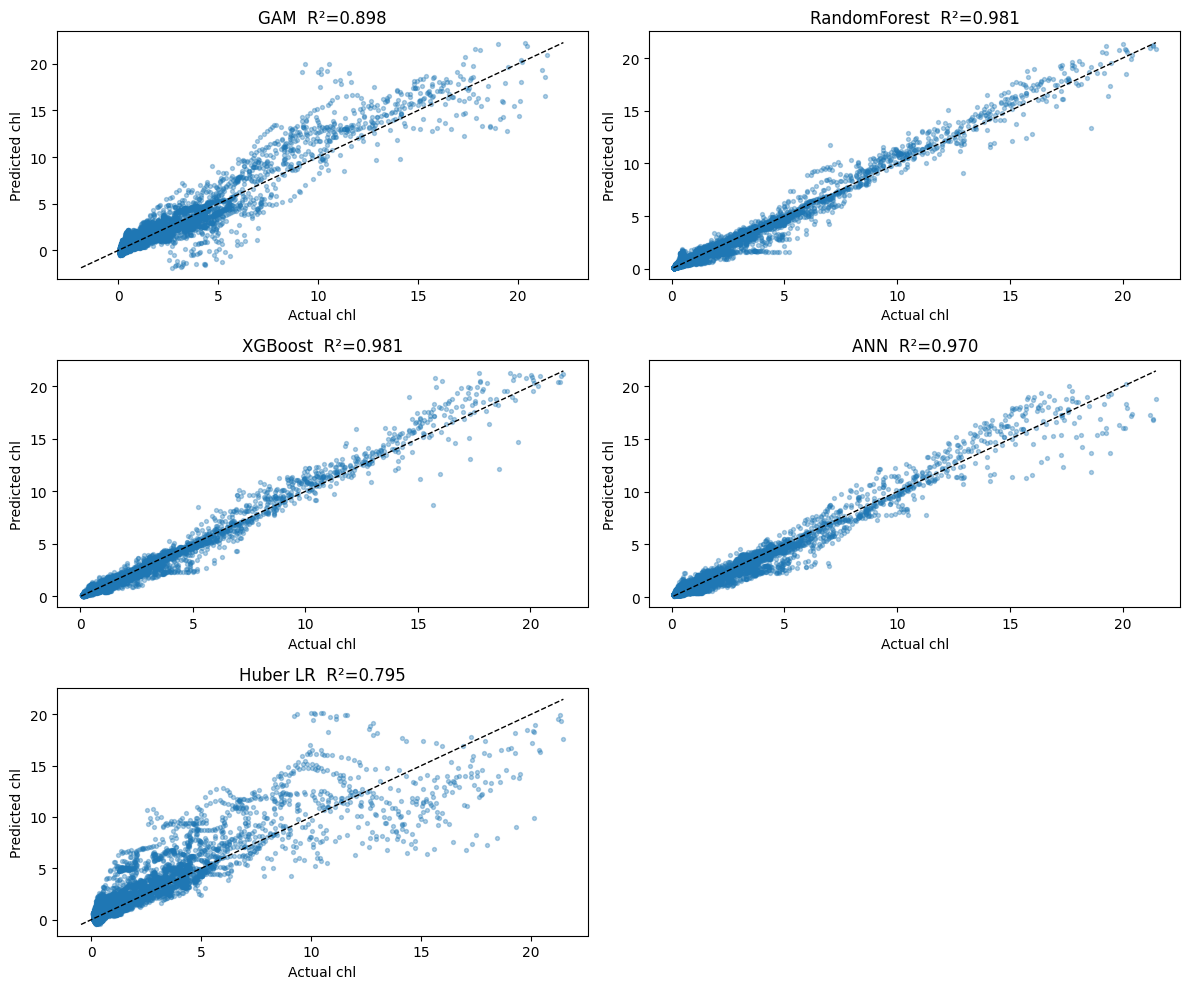

In [6]:
# Predicted vs actual on temporal holdout (full feature set)

plt.figure(figsize=(12, 10))
for i, (name, preds) in enumerate(preds_full.items(), start=1):
    plt.subplot(3, 2, i)
    plt.scatter(y_test, preds, s=8, alpha=0.35)
    mn = min(y_test.min(), preds.min())
    mx = max(y_test.max(), preds.max())
    plt.plot([mn, mx], [mn, mx], "k--", linewidth=1)
    plt.xlabel(f"Actual {TARGET}")
    plt.ylabel(f"Predicted {TARGET}")
    plt.title(f"{name}  R²={r2_score(y_test, preds):.3f}")
plt.tight_layout()
plt.show()
